In [1]:
import numpy as np
import pandas as pd
import scipy 
import matplotlib.pyplot as plt


Text(0, 0.5, 'Tiempo de residencia ($s^{-1}$)')

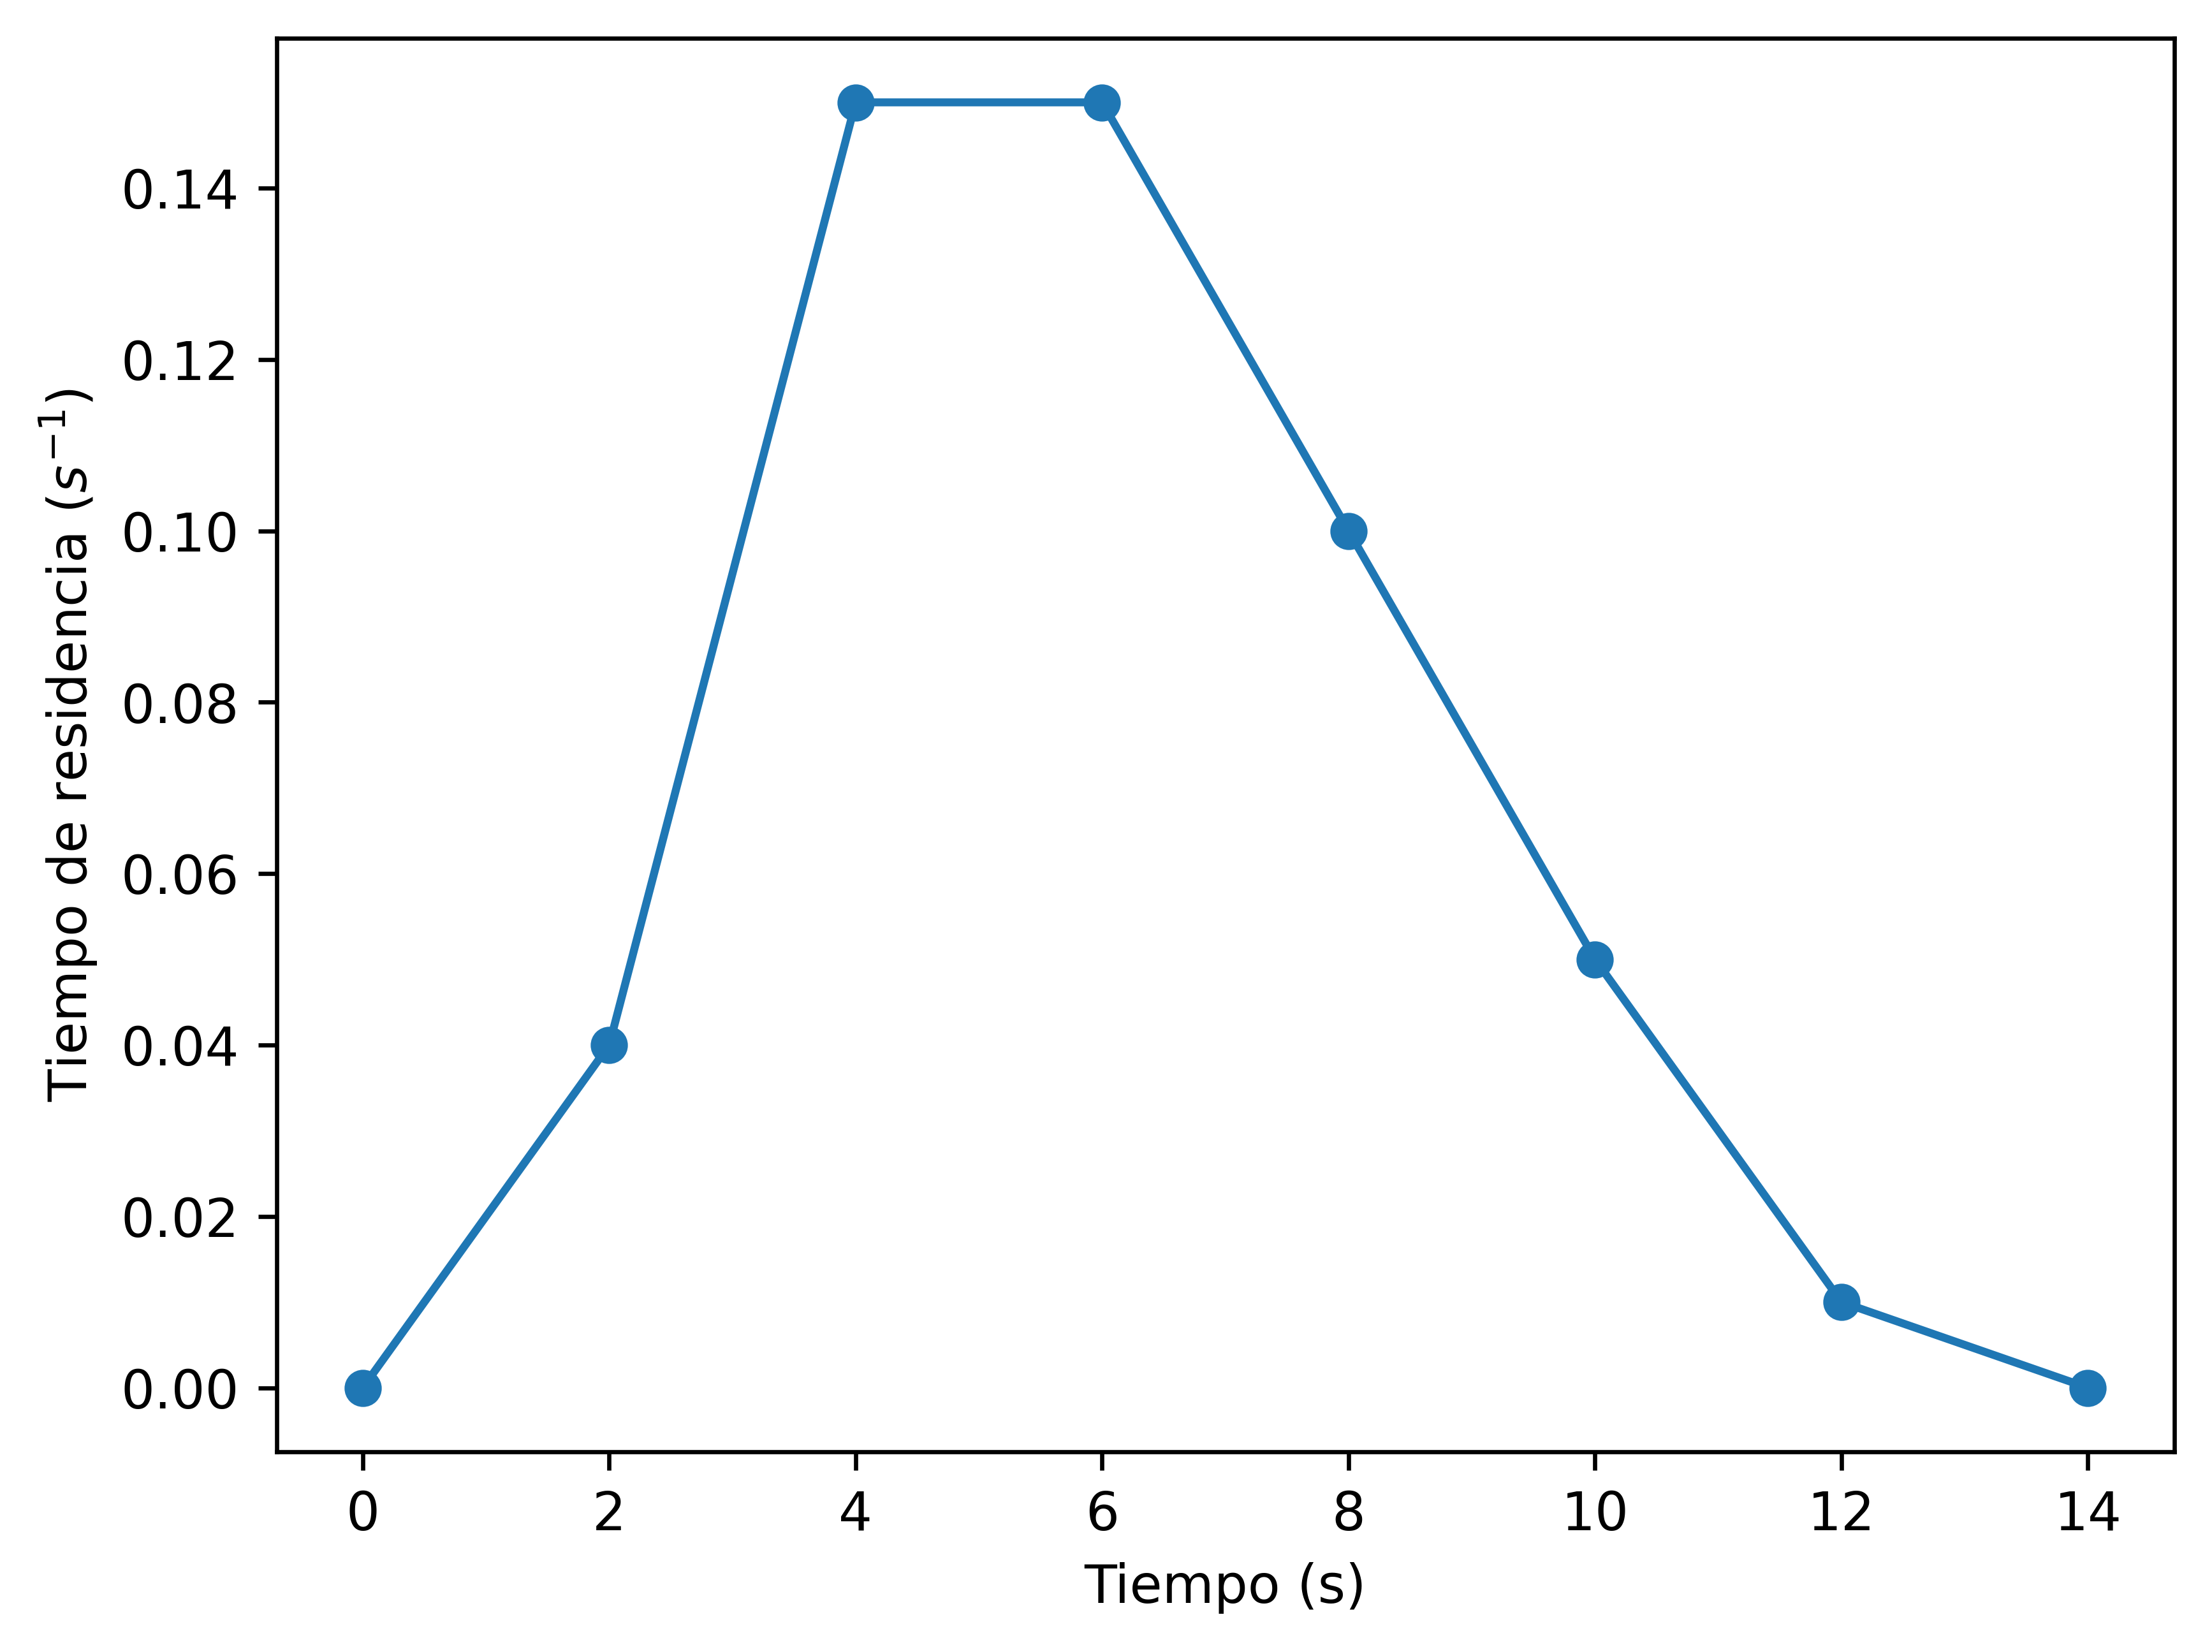

In [2]:
residency = {
    't': [0, 2, 4, 6, 8, 10, 12, 14],
    'E': [0.00, 0.04, 0.15, 0.15, 0.10, 0.05, 0.01, 0.00]
}
df = pd.DataFrame(residency)
fig, ax = plt.subplots( dpi = 600)
ax.plot(df['t'], df['E'], marker='o')
ax.set_xlabel('Tiempo (s)')   
ax.set_ylabel('Tiempo de residencia ($s^{-1}$)')

In [3]:
k = 0.307
CA_ca0 = np.sum(df['E'] * np.exp(-k * df['t']) * (df['t'][1] - df['t'][0]))


# 2

In [4]:

df_2 = pd.DataFrame({
    't': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'C': [0, 40, 75, 120, 200, 350, 500, 400, 280, 120, 0]
})

df_2['t'] = df_2['t'] / 60 # Convertir minutos a horas

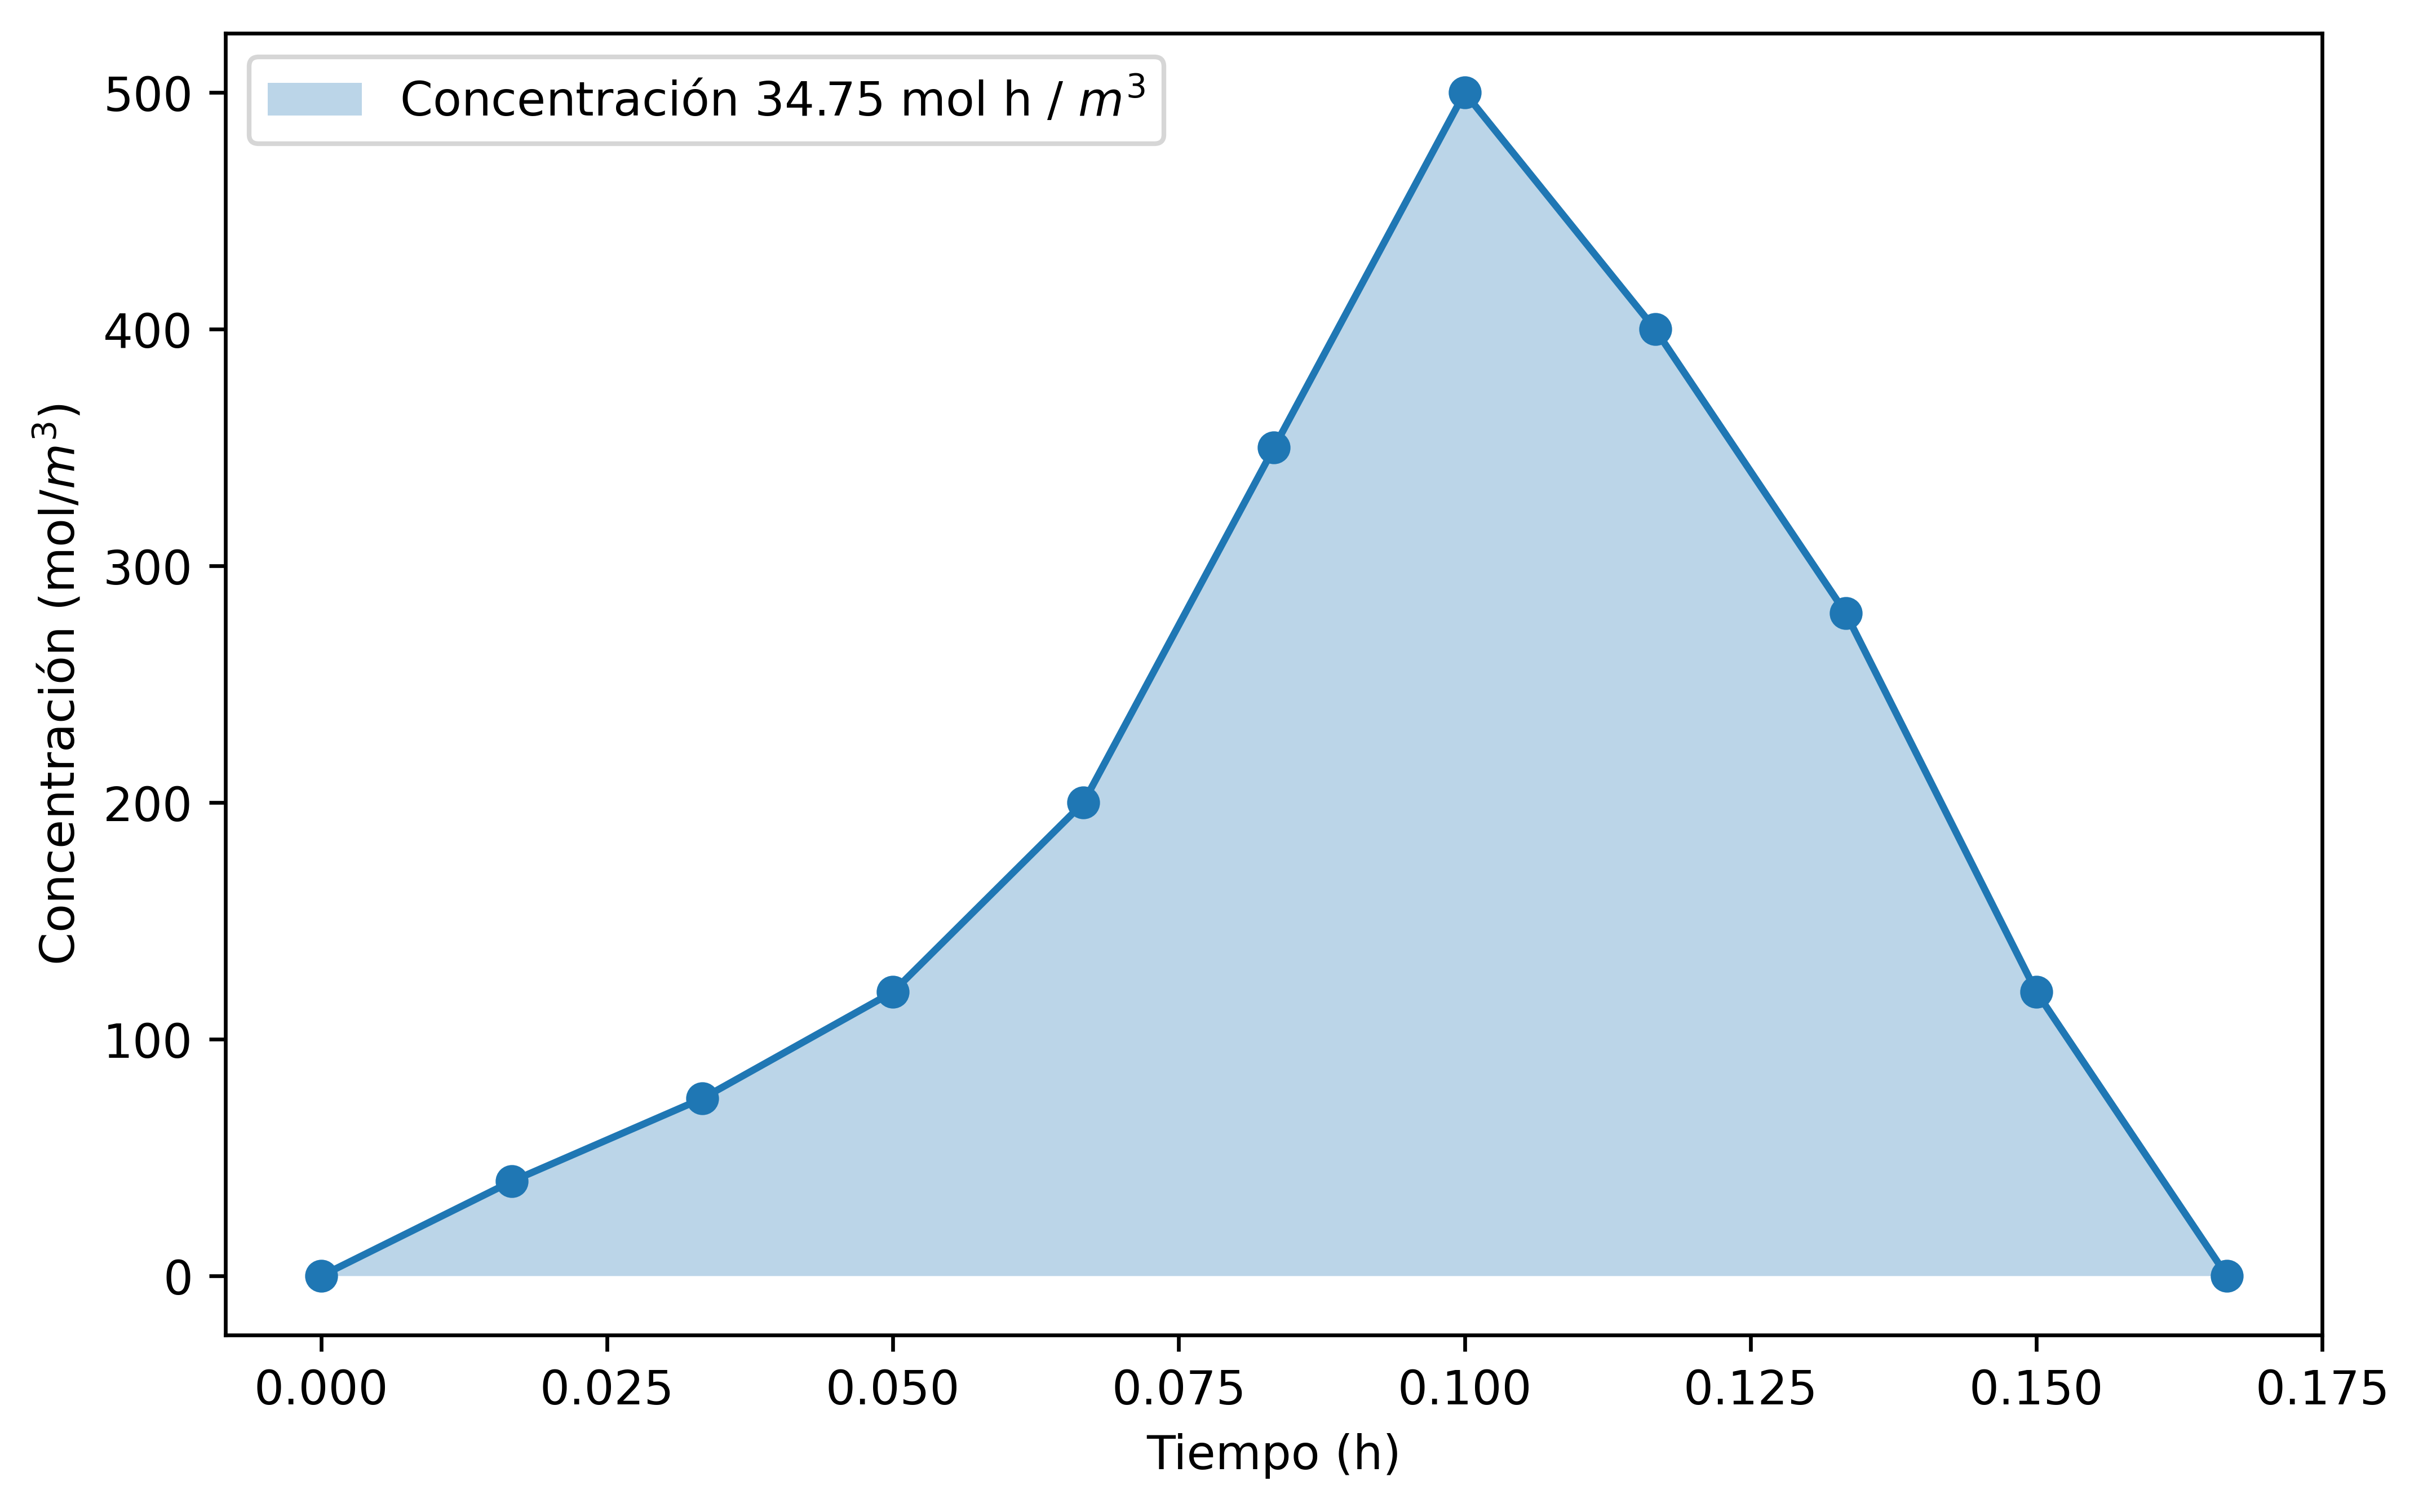

In [5]:
area_under_curve_C= np.trapezoid(df_2['C'], df_2['t'])

fig, ax = plt.subplots(dpi=600, figsize=(8, 5))
ax.plot(df_2['t'], df_2['C'], marker='o')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Concentración (mol/$m^3$)')
ax.fill_between(df_2['t'], df_2['C'], alpha=0.3, label = f'Concentración {area_under_curve_C:.2f} mol h / $m^3$')
ax.legend()
plt.show()


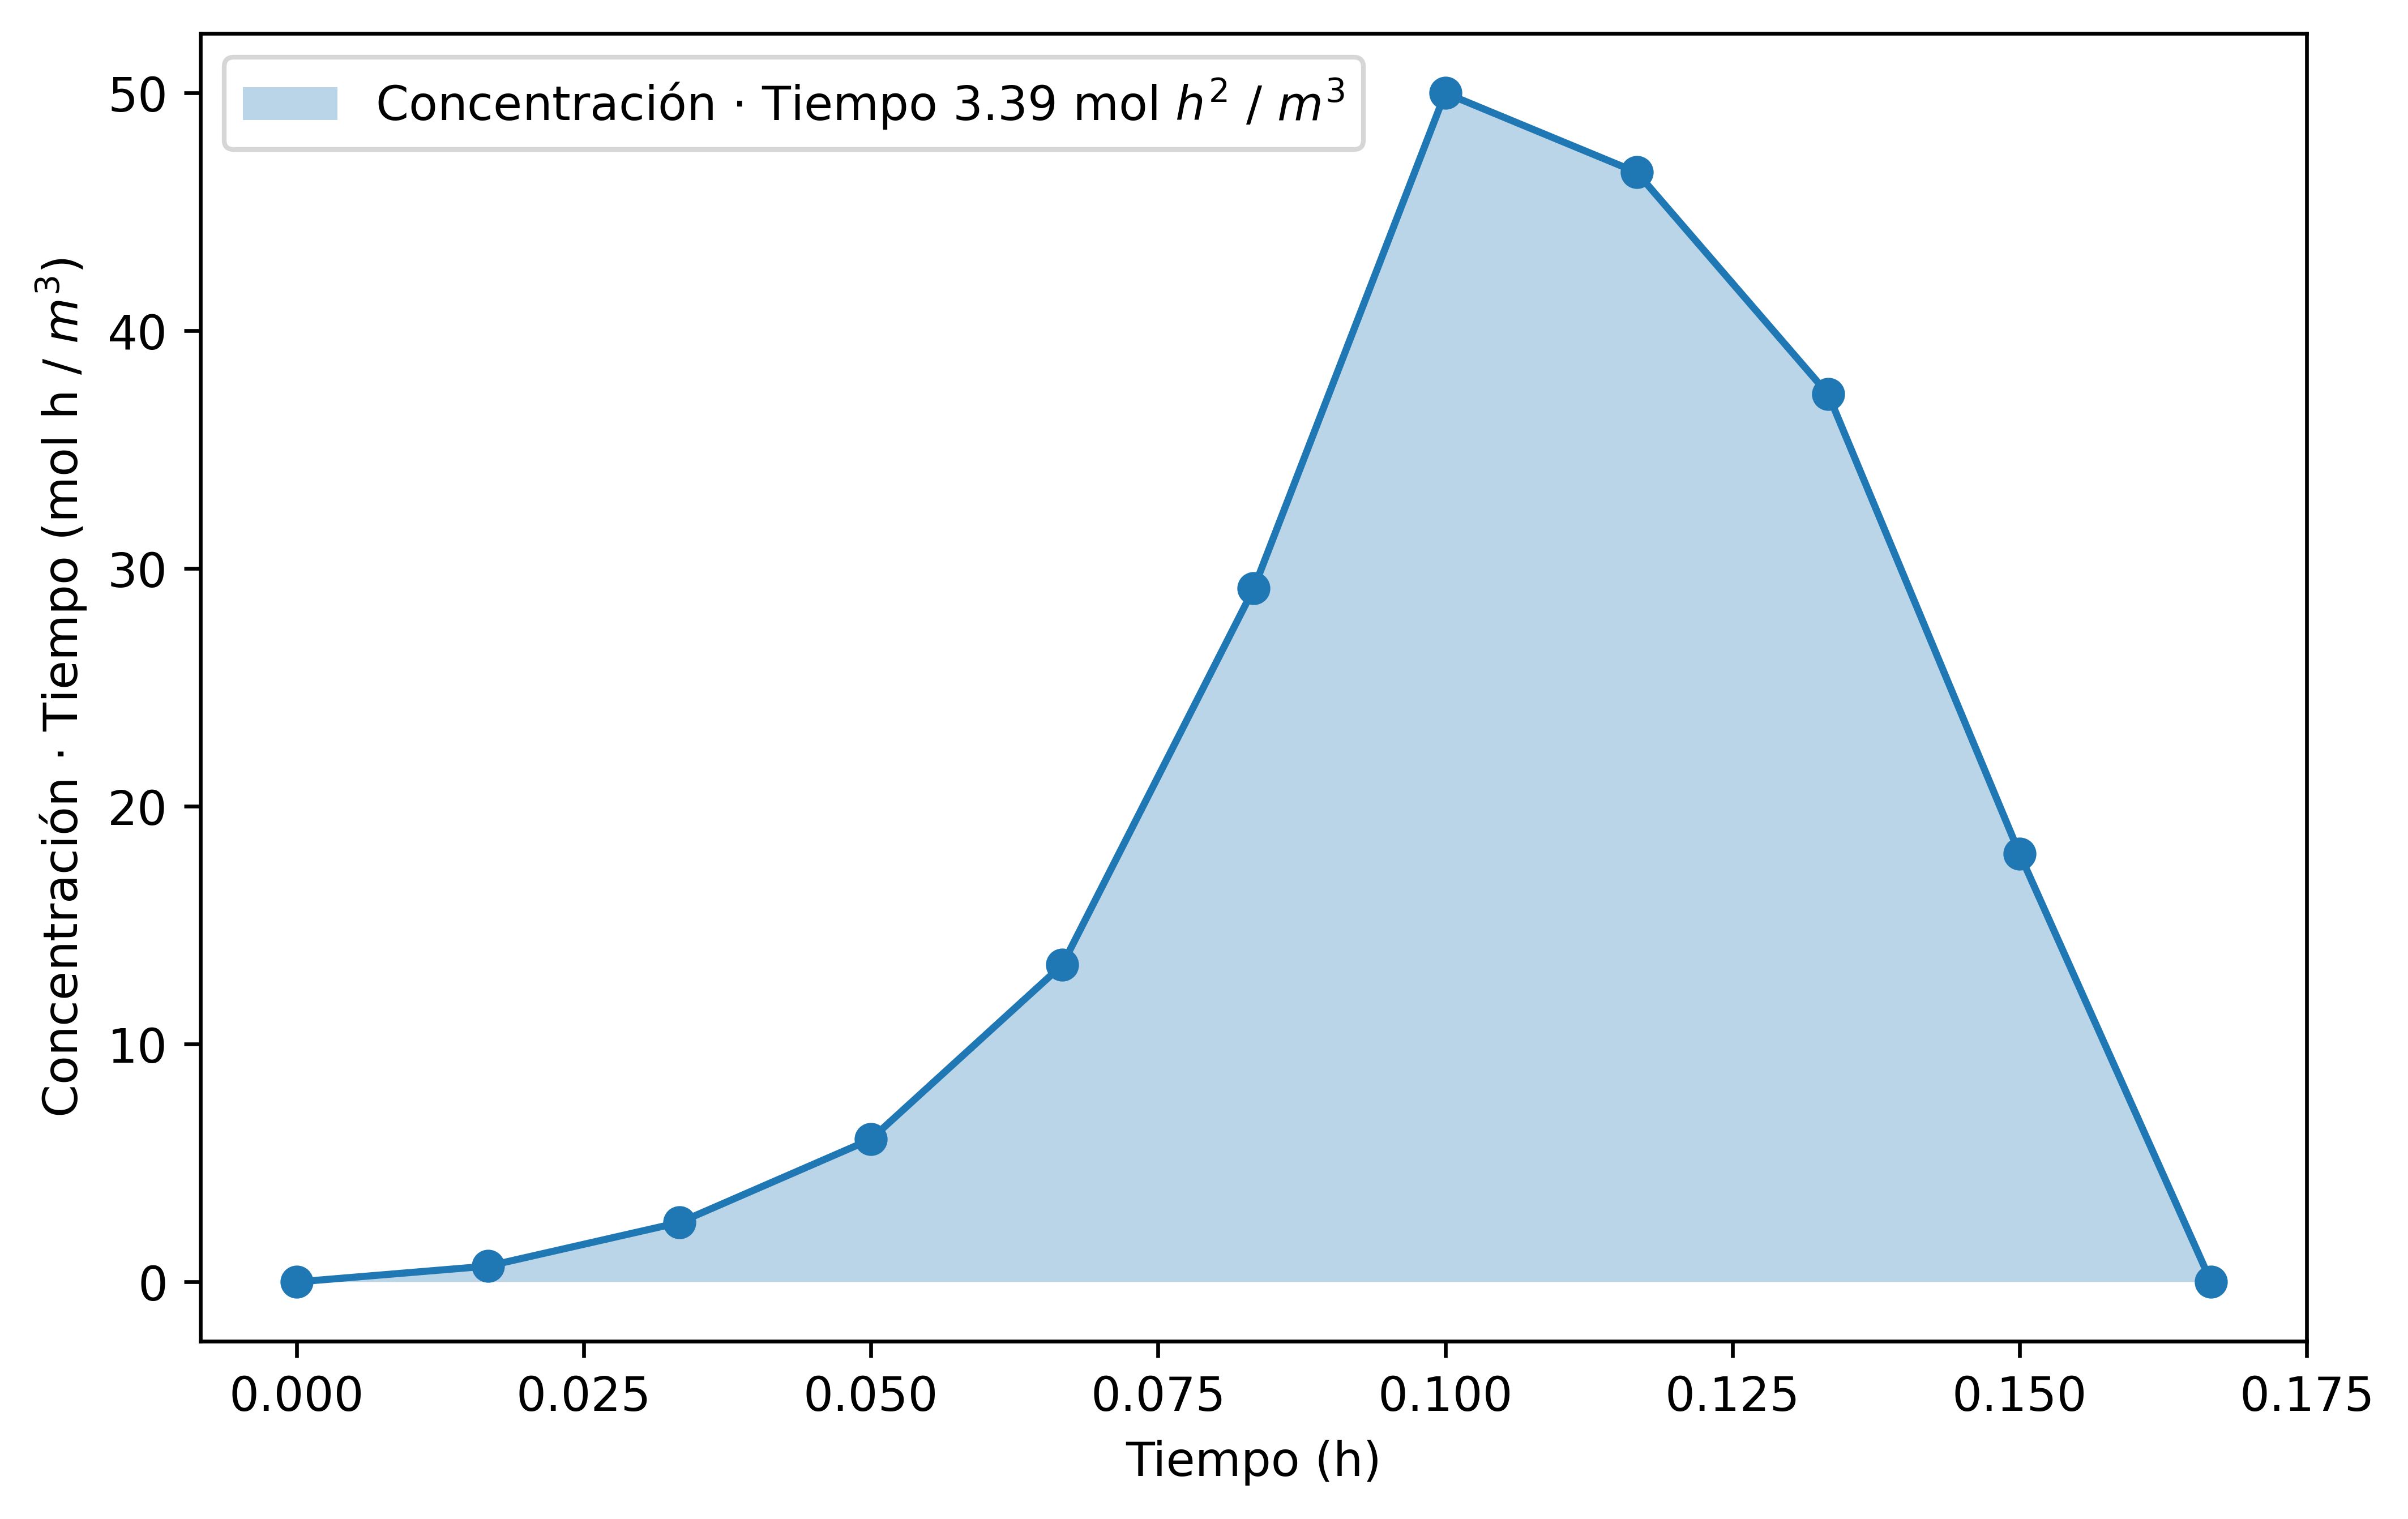

In [6]:
df_2['X t'] = df_2['C'] * df_2['t']
area_under_curve_Xt = np.trapezoid(df_2['X t'], df_2['t'])
fig, ax = plt.subplots(dpi=600, figsize=(8, 5))
ax.plot(df_2['t'], df_2['X t'], marker='o')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Concentración $\\cdot$ Tiempo (mol h / $m^3$)')
ax.fill_between(df_2['t'], df_2['X t'], alpha=0.3, label = f'Concentración $\\cdot$ Tiempo {area_under_curve_Xt:.2f} mol $h^2$ / $m^3$')
ax.legend()
plt.show()

/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_48899/3532394568.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


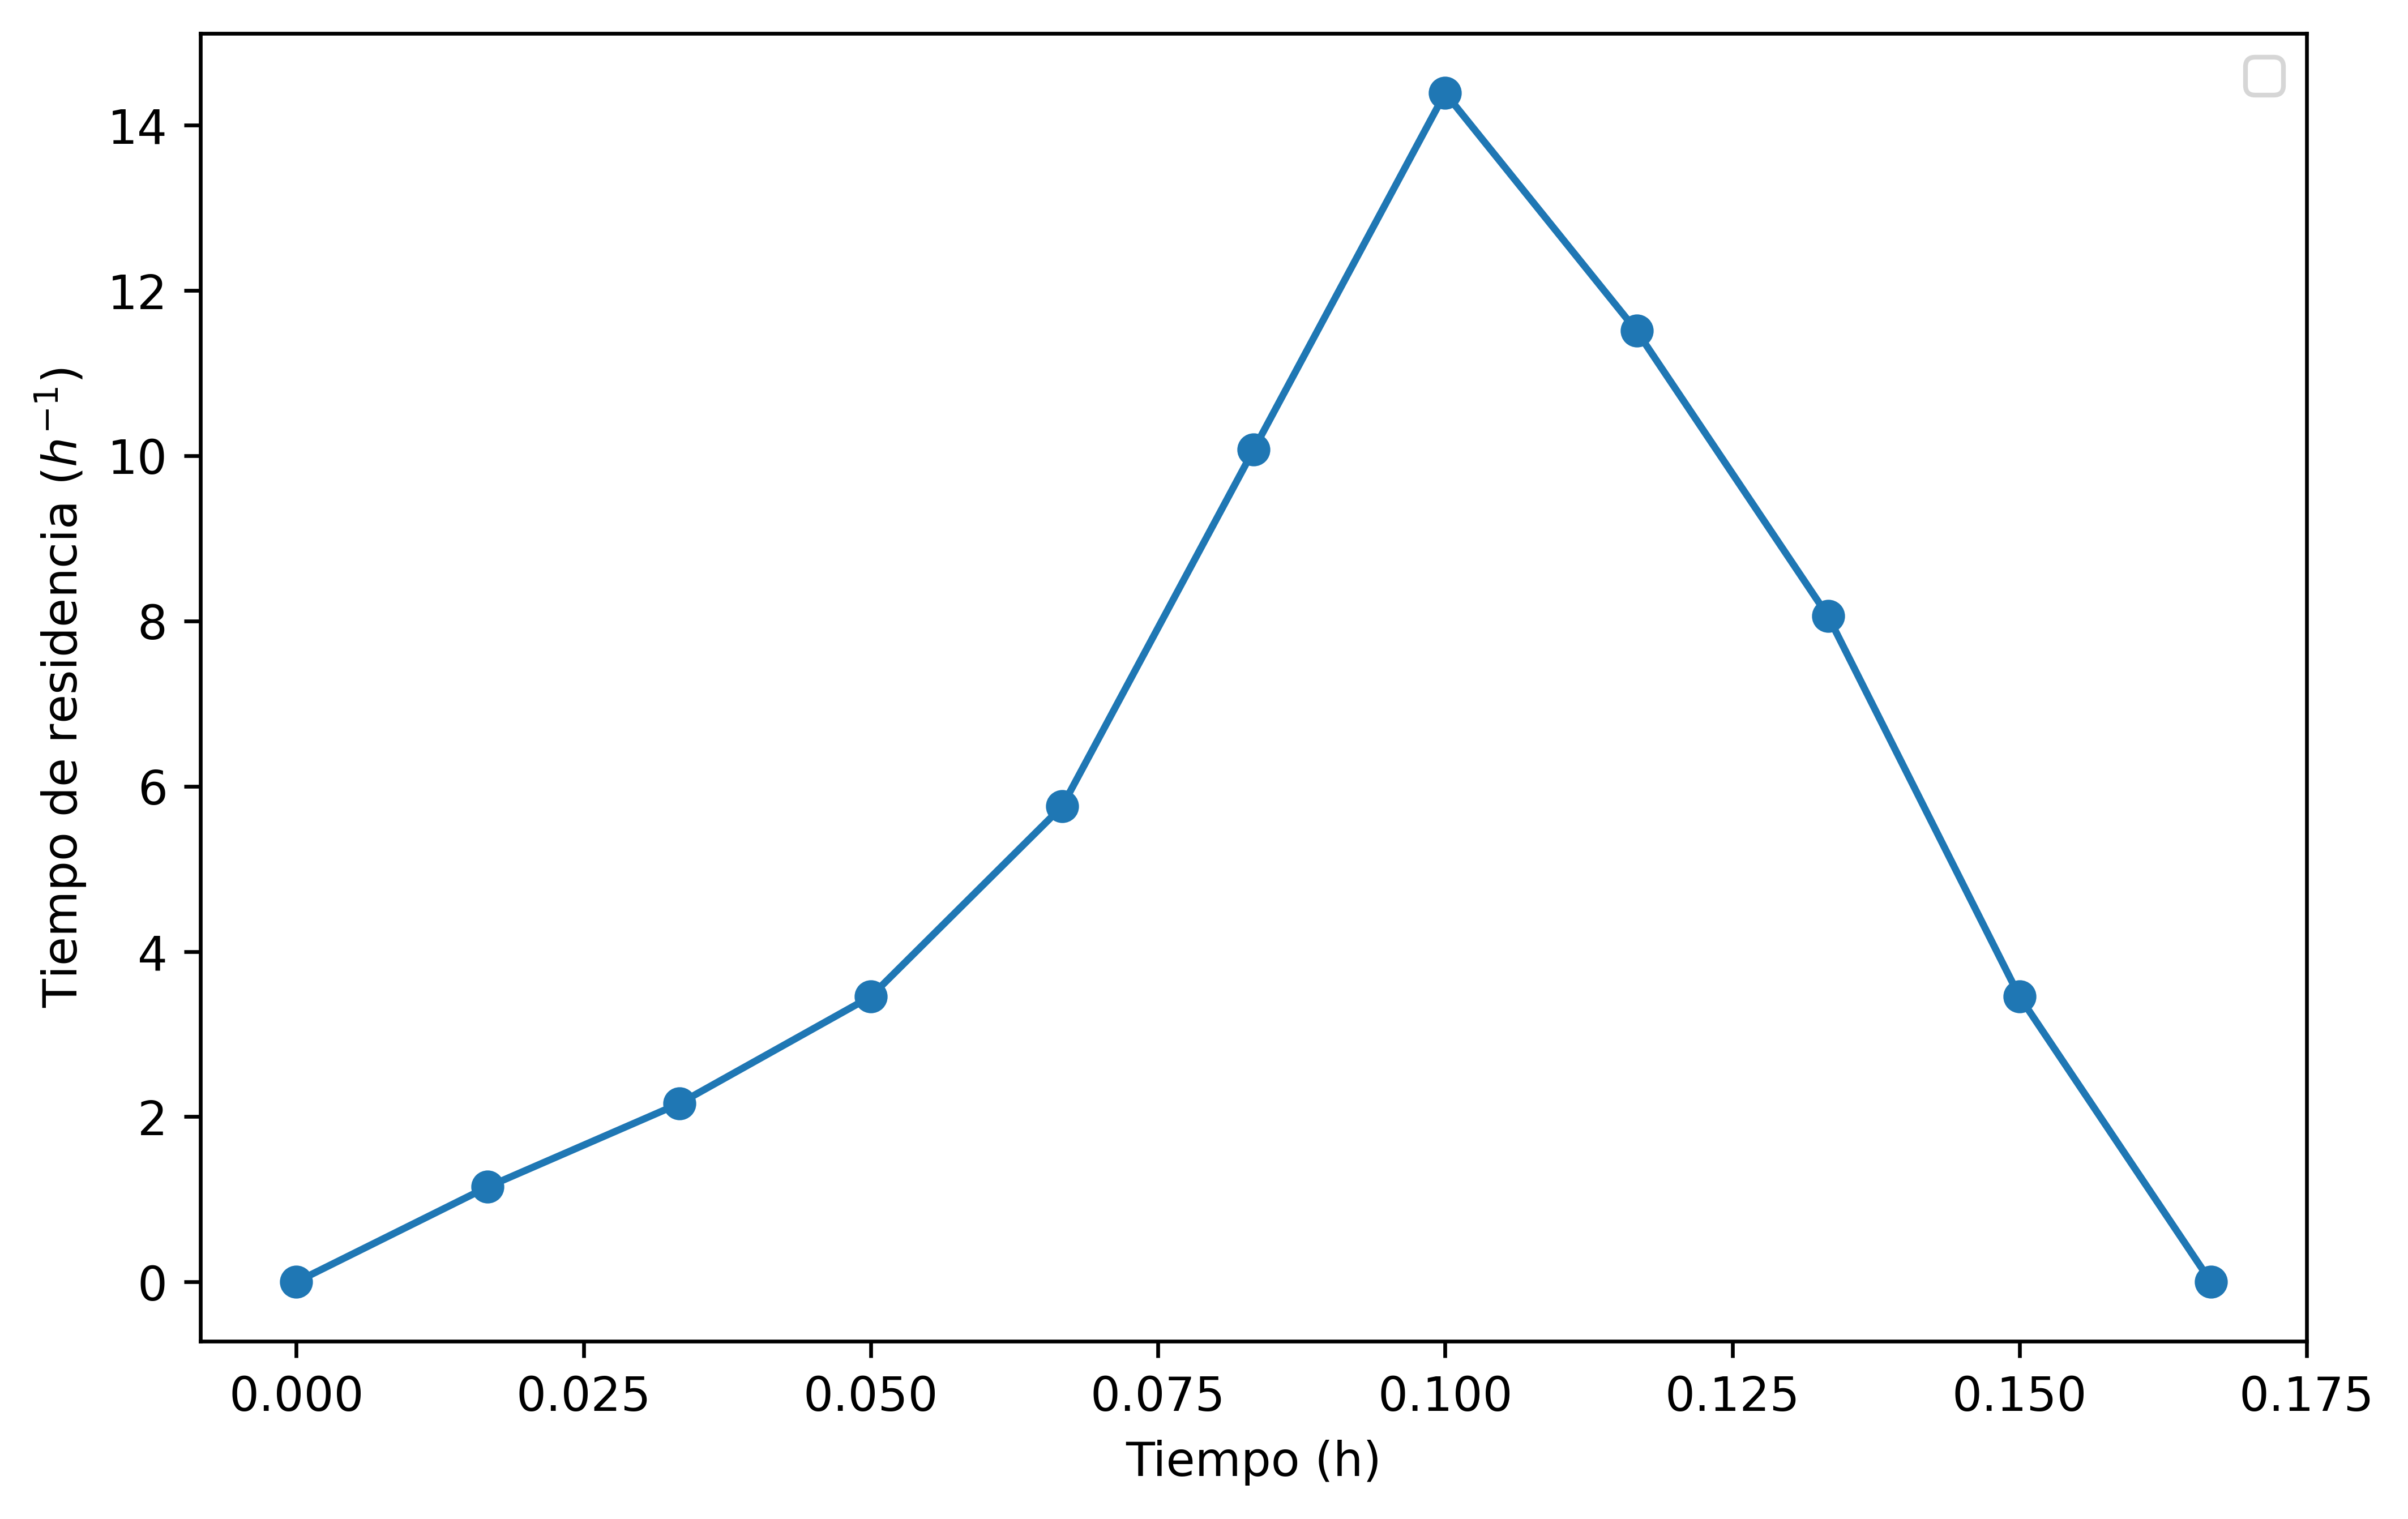

In [7]:
df_2['E'] = df_2['C'] / area_under_curve_C
fig, ax = plt.subplots(dpi=600, figsize=(8, 5))
ax.plot(df_2['t'], df_2['E'], marker='o')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Tiempo de residencia ($h^{-1}$)')
ax.legend()

/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_48899/324412111.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


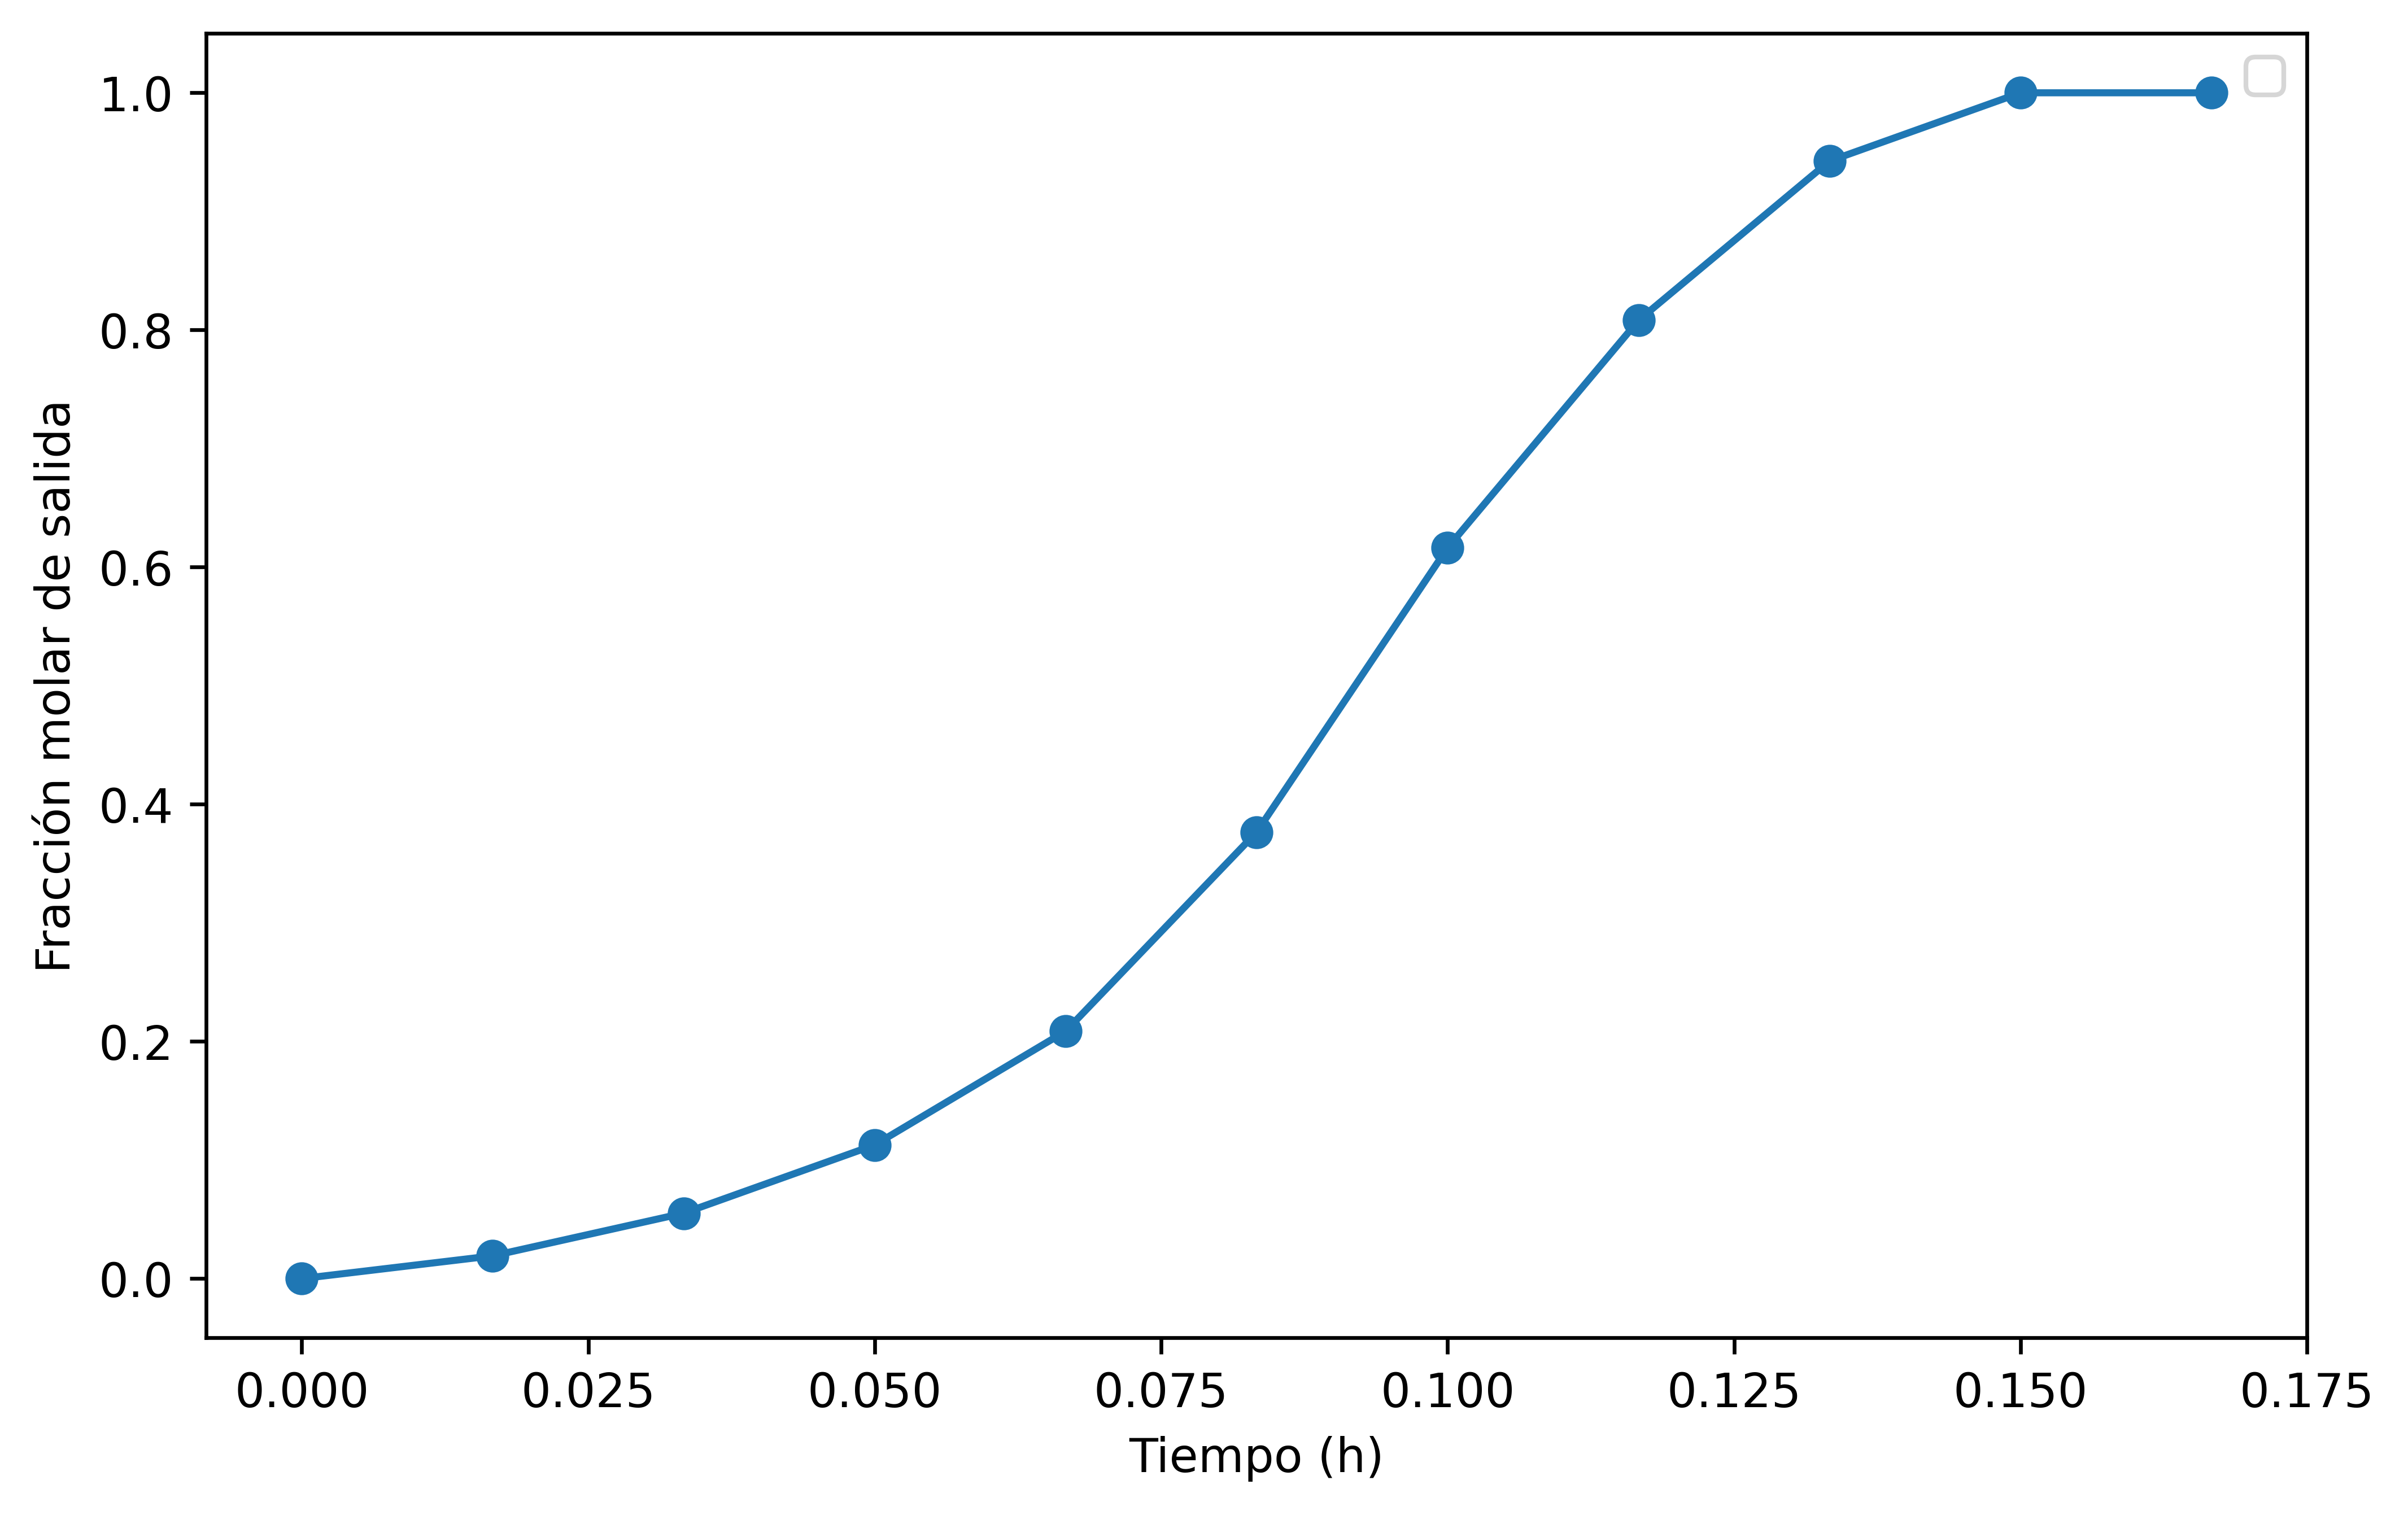

In [8]:
df_2['F'] = np.cumsum(df_2['E'] * (df_2['t'][1] - df_2['t'][0]))
fig, ax = plt.subplots(dpi=600, figsize=(8, 5))
ax.plot(df_2['t'], df_2['F'], marker='o')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Fracción molar de salida')
ax.legend()

# 3

In [9]:
t_min = 10.0  # enunciado: tiempo mínimo de residencia (p. ej., 10 min)

# tiempos medios de residencia (para comparación)
tau_lam = 2.0 * t_min      # flujo laminar
tau_turb = 1.24 * t_min    # flujo turbulento

B = 0.404  # valor de la función Beta usada en el caso turbulento

# Definiciones de E(t)
def E_laminar(t, t_min):
    E = np.zeros_like(t, dtype=float)
    mask = t >= t_min
    E[mask] = 2.0 * (t_min**2) / (t[mask]**3)
    return E

def E_turbulento(t, t_min, B):
    E = np.zeros_like(t, dtype=float)
    mask = t >= t_min
    E[mask] = (7.0 / (B * t_min)) * (1.0 - (t_min / t[mask])**7) * (t_min / t[mask])**9
    return E

def E_CSTR(t, tau):
    E = np.zeros_like(t, dtype=float)
    mask = t >= 0
    E[mask] = (1.0 / tau) * np.exp(-t[mask] / tau)
    return E

# No es necesario definir E_PFR: es un delta (pico) en t = tau.
t = np.linspace(0.0, 100.0, 1000)

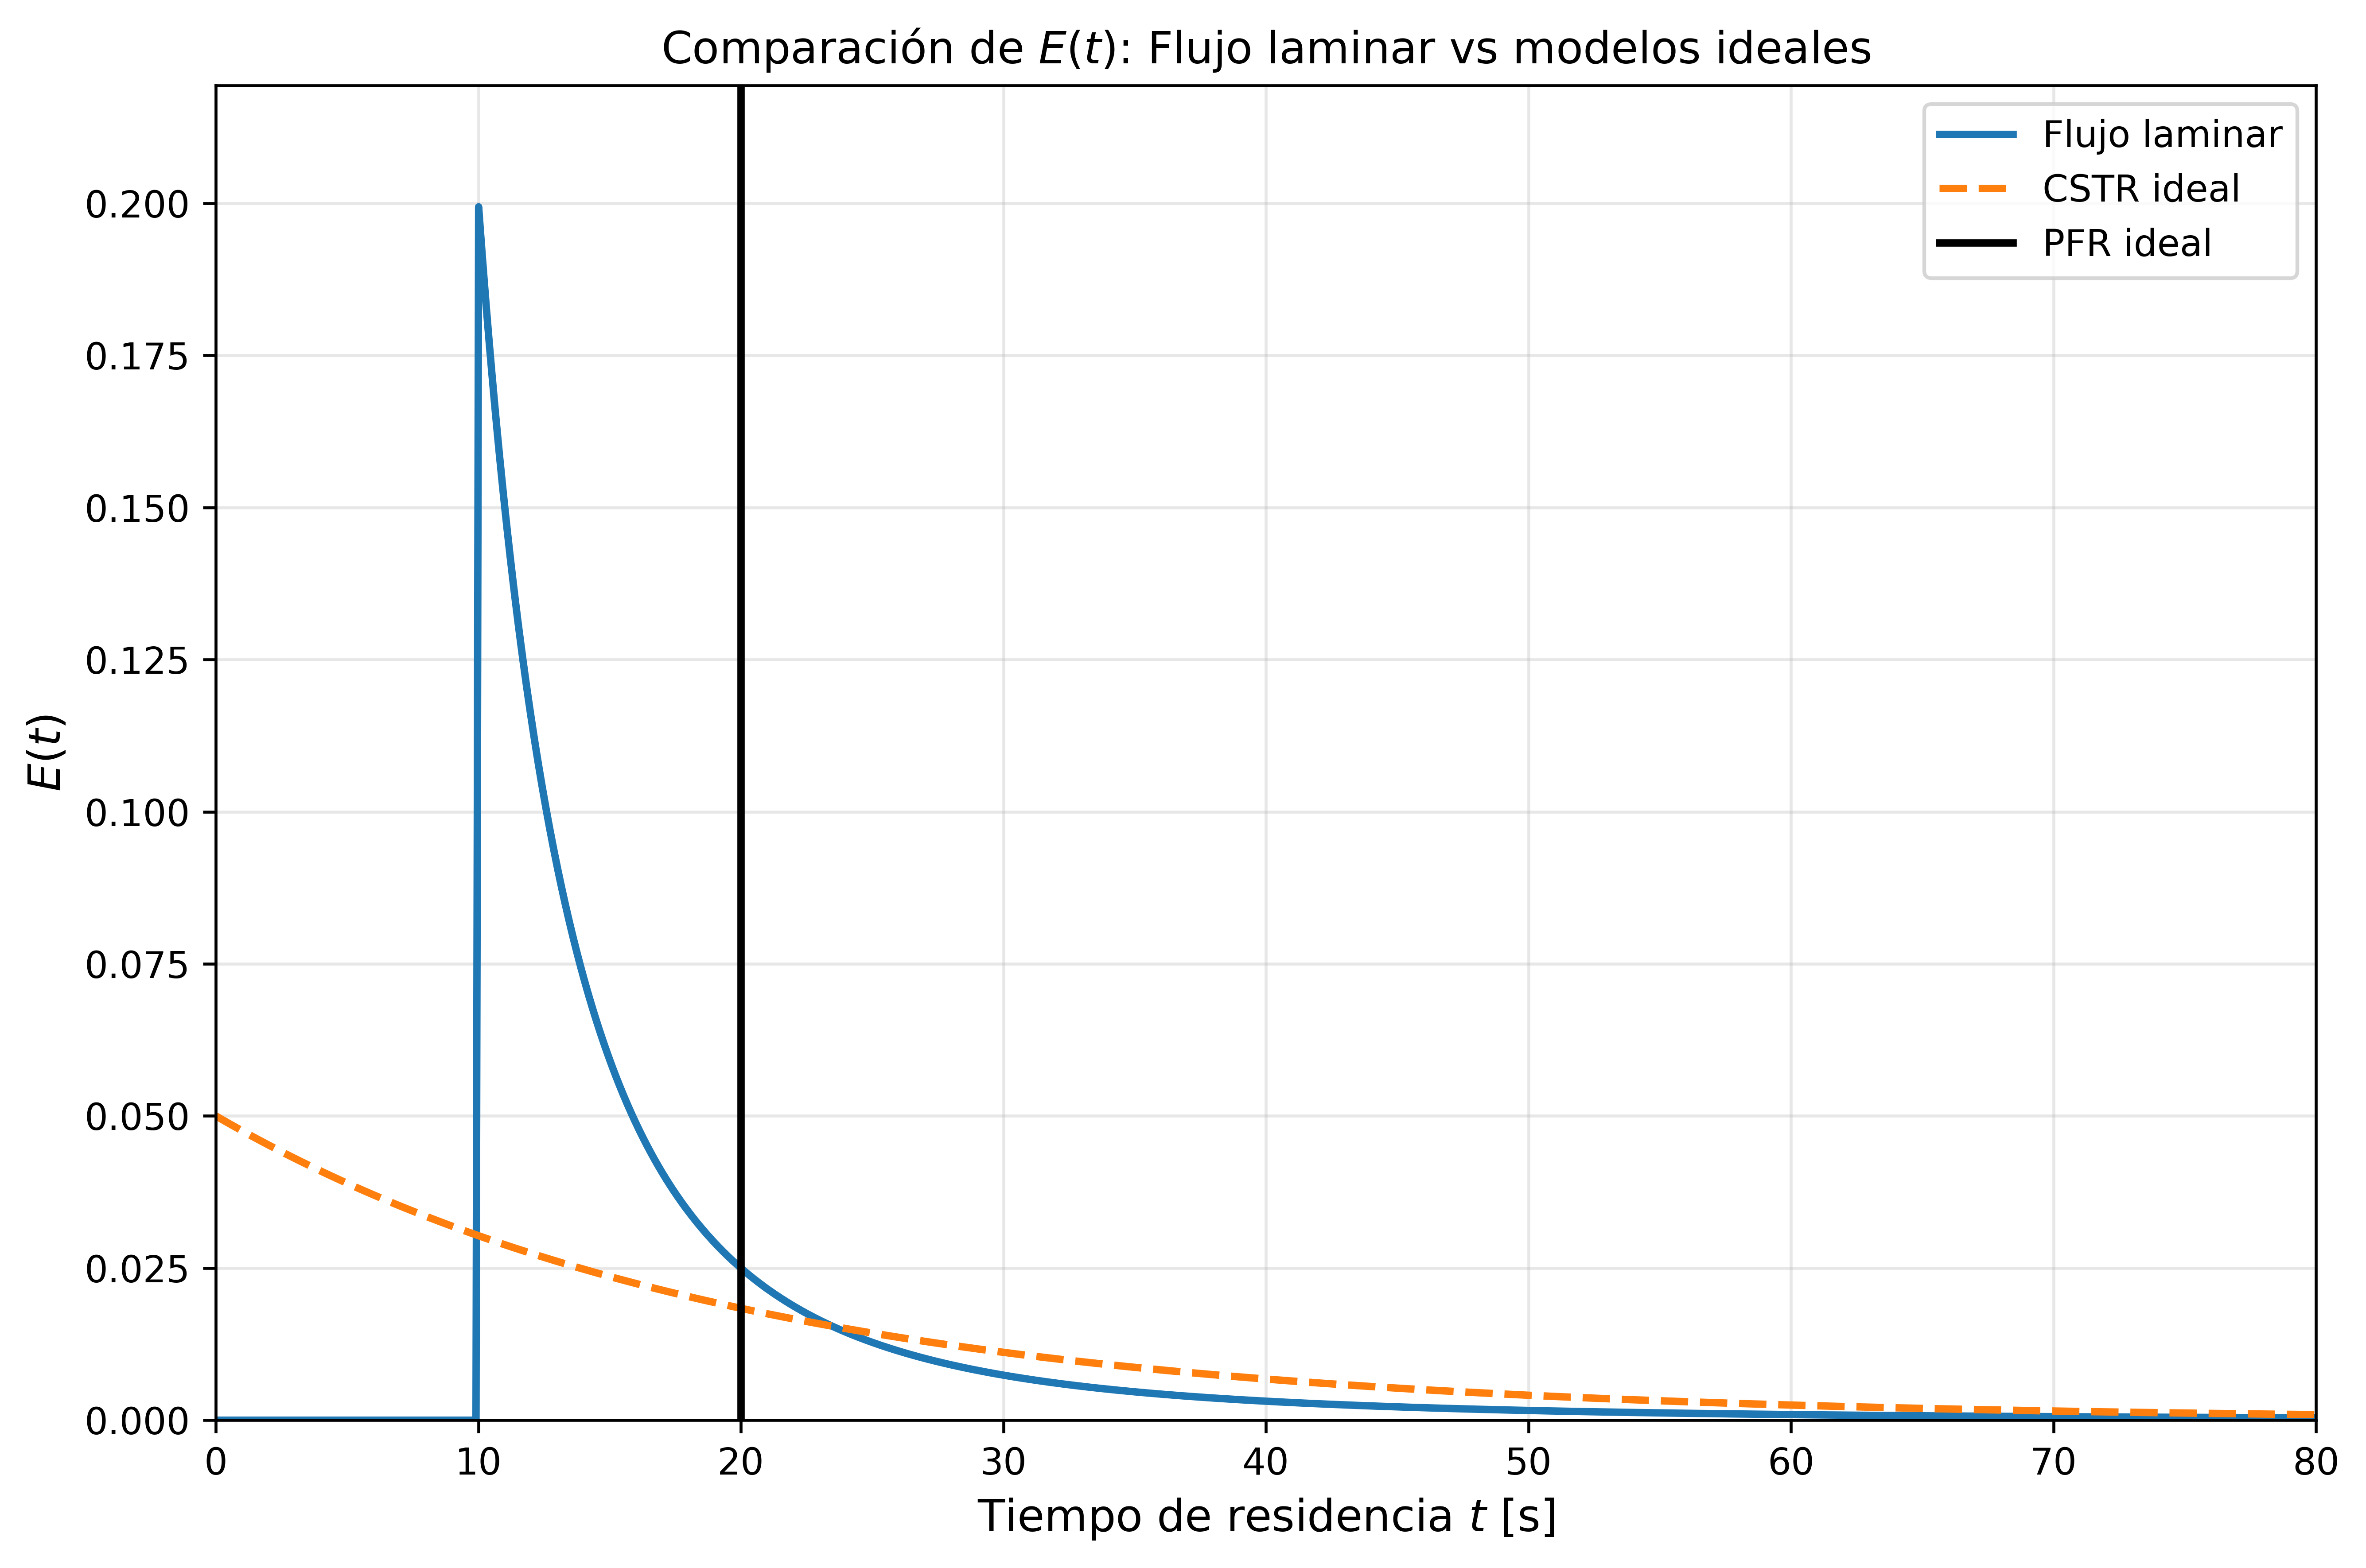

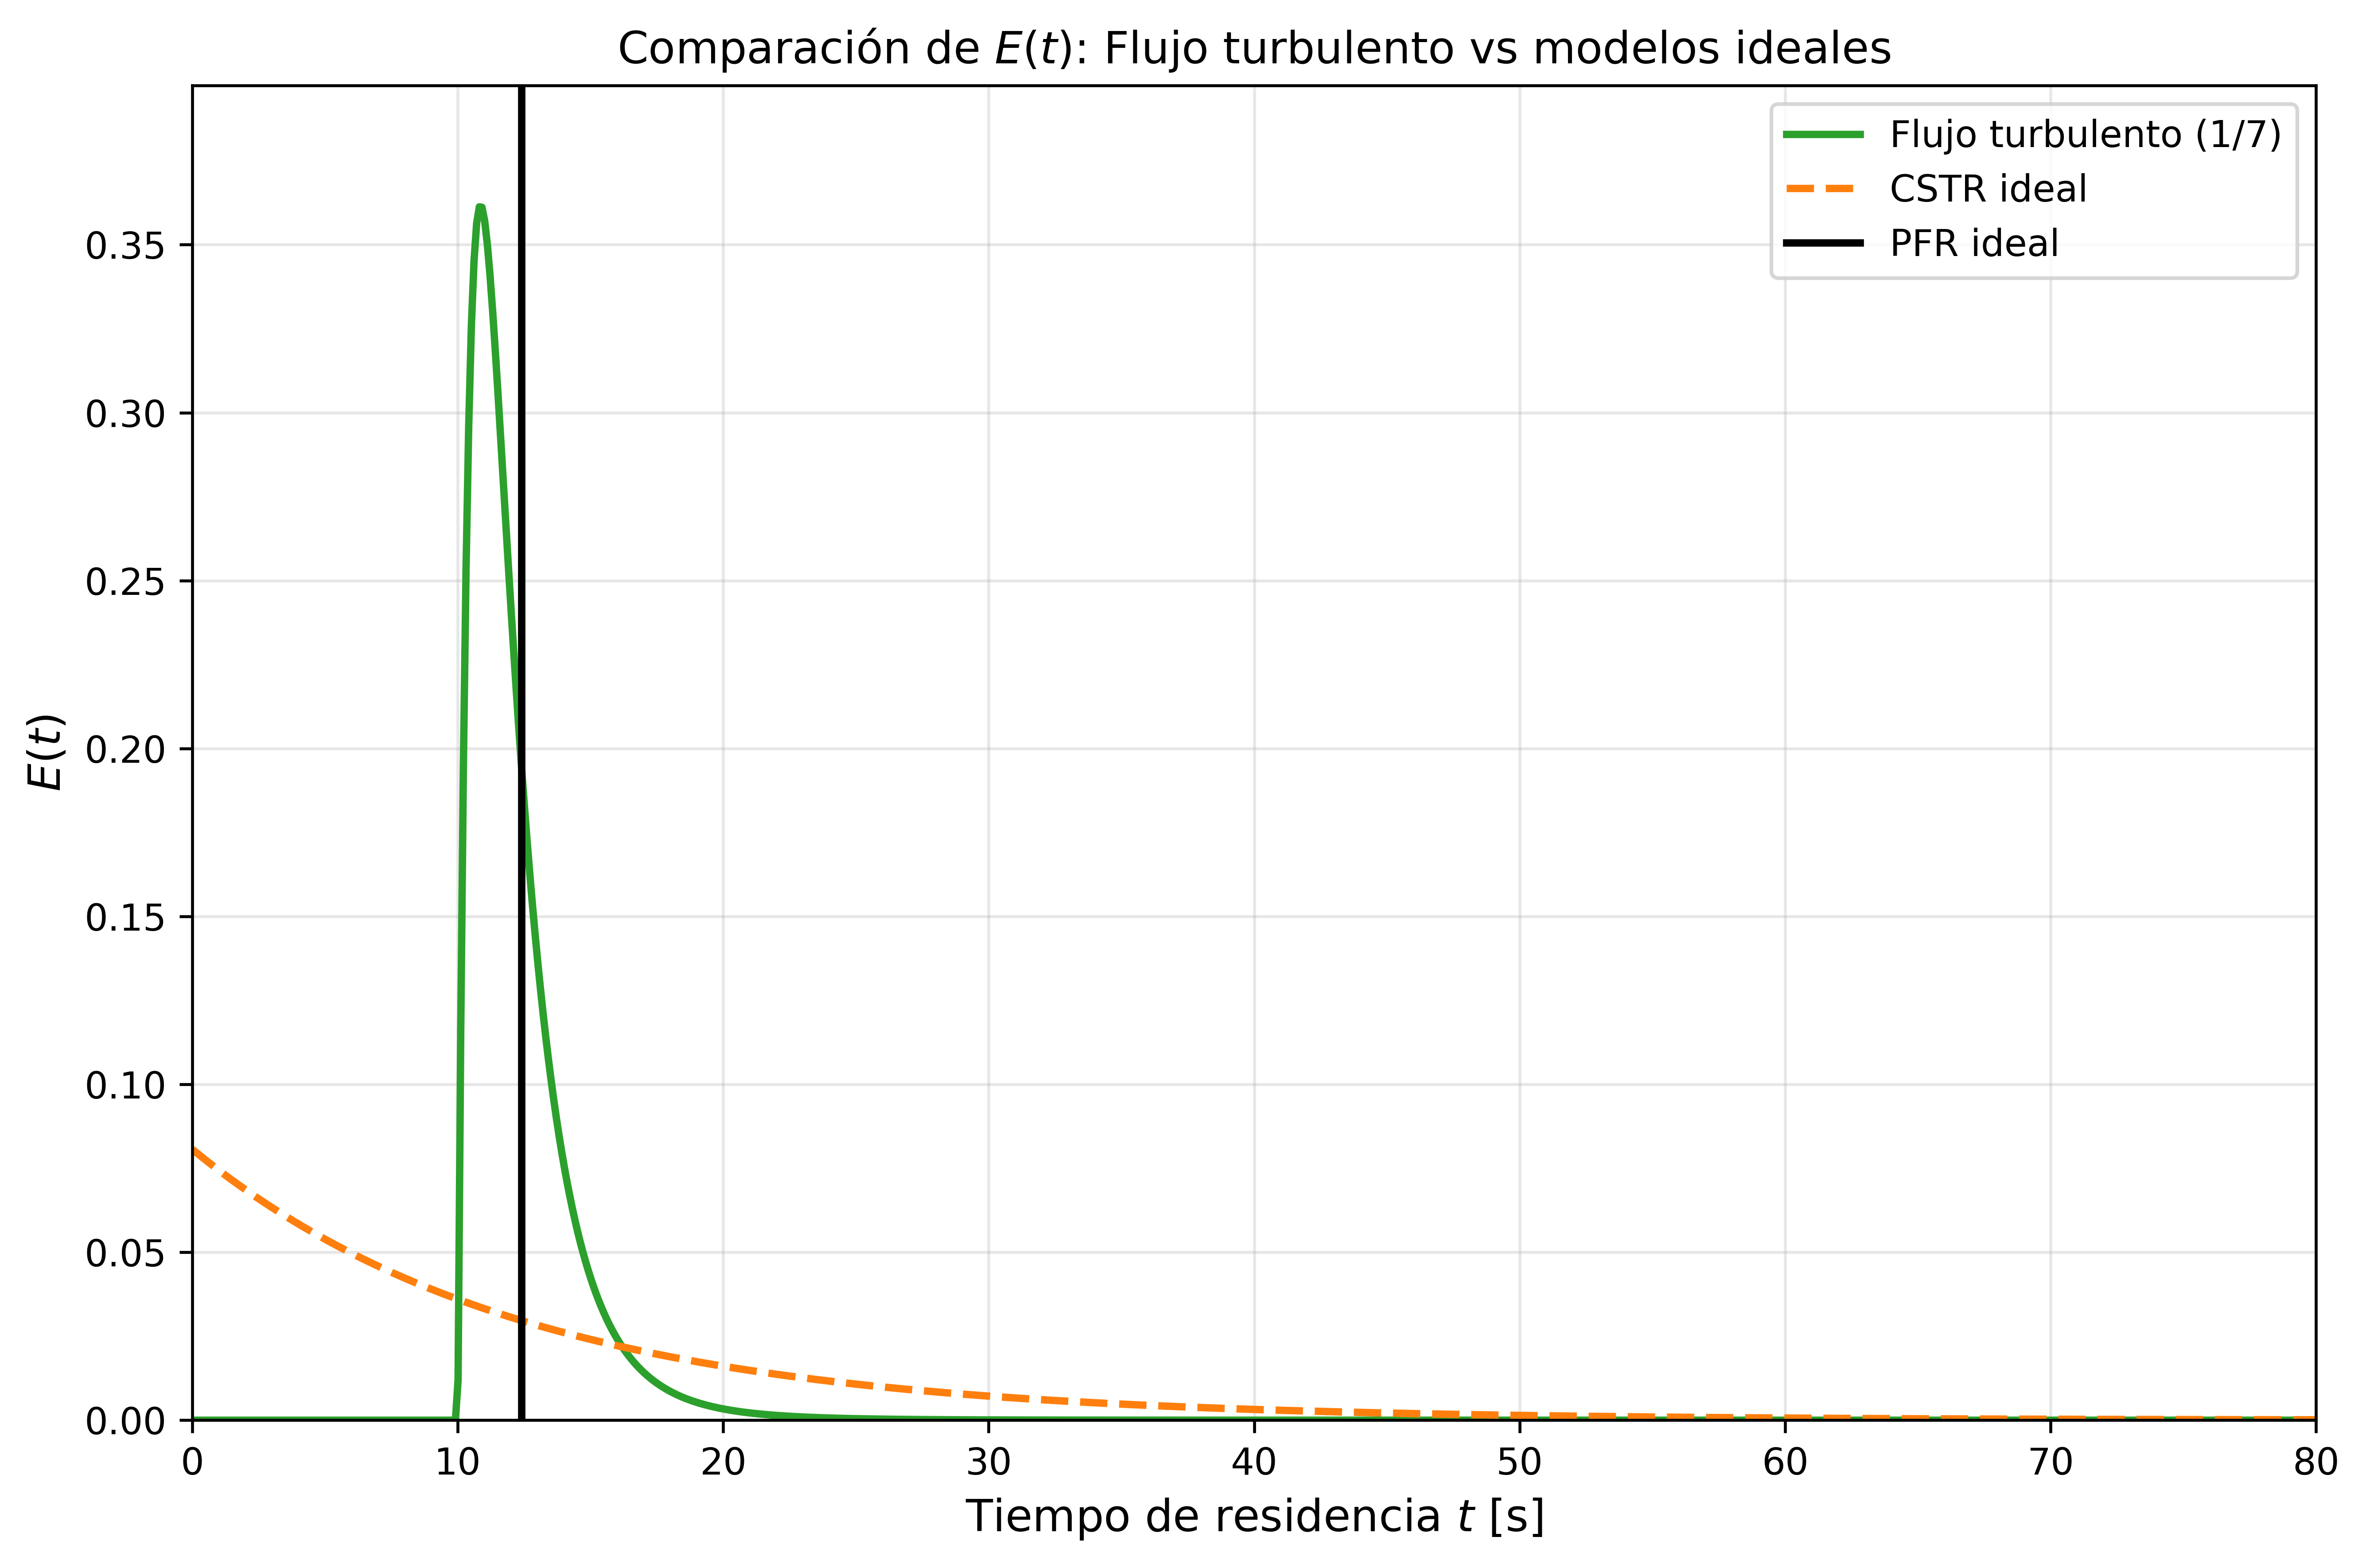

In [11]:
E_lam = E_laminar(t, t_min)
E_turb = E_turbulento(t, t_min, B)

E_cstr_lam = E_CSTR(t, tau_lam)
E_cstr_turb = E_CSTR(t, tau_turb)


plt.figure(figsize=(9, 6), dpi = 600)
plt.plot(t, E_lam, label=r"Flujo laminar", lw=2, color="C0")
plt.plot(t, E_cstr_lam, "--", color="C1", lw=2, label=r"CSTR ideal")
plt.axvline(x=tau_lam, color="k", lw=2, label=r"PFR ideal")

ymax = 1.1 * max(E_lam.max(), E_cstr_lam.max())
plt.ylim(0, ymax)
plt.xlim(0, 80)
plt.xlabel(r"Tiempo de residencia $t$ [s]", fontsize=12)
plt.ylabel(r"$E(t)$", fontsize=12)
plt.title(r"Comparación de $E(t)$: Flujo laminar vs modelos ideales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 6), dpi = 600)
plt.plot(t, E_turb, label=r"Flujo turbulento (1/7)", lw=2, color="C2")
plt.plot(t, E_cstr_turb, "--", color="C1", lw=2, label=r"CSTR ideal")
plt.axvline(x=tau_turb, color="k", lw=2, label=r"PFR ideal")

ymax = 1.1 * max(E_turb.max(), E_cstr_turb.max())
plt.ylim(0, ymax)
plt.xlim(0, 80)
plt.xlabel(r"Tiempo de residencia $t$ [s]", fontsize=12)
plt.ylabel(r"$E(t)$", fontsize=12)
plt.title(r"Comparación de $E(t)$: Flujo turbulento vs modelos ideales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
